In [5]:
from pathlib import Path

print("Current folder:")
print(Path.cwd())

print("\nFolders available:")
for item in Path.cwd().iterdir():
    print(item.name)

Current folder:
c:\Users\HP\OneDrive\Desktop\illegal mining.data\notebooks

Folders available:
01_dataset_analysis.ipynb


In [6]:
from pathlib import Path

# Get the main project folder
project_path = Path.cwd().parent

# Dataset folder
dataset_path = project_path / "Imagens_Dataset_Garimpo"

# Class folders
mining_path = dataset_path / "Imagens - Garimpo"
non_mining_path = dataset_path / "Imagens - Rios_Floresta"

print("Project folder:")
print(project_path)

print("\nDataset folder:")
print(dataset_path)

print("\nMining folder exists:", mining_path.exists())
print("Non-mining folder exists:", non_mining_path.exists())

Project folder:
c:\Users\HP\OneDrive\Desktop\illegal mining.data

Dataset folder:
c:\Users\HP\OneDrive\Desktop\illegal mining.data\Imagens_Dataset_Garimpo

Mining folder exists: False
Non-mining folder exists: False


In [8]:
from pathlib import Path

print("CURRENT NOTEBOOK LOCATION:")
print(Path.cwd())

print("\nFOLDERS ONE LEVEL ABOVE:")
parent = Path.cwd().parent

for item in parent.iterdir():
    print(repr(item.name))

CURRENT NOTEBOOK LOCATION:
c:\Users\HP\OneDrive\Desktop\illegal mining.data\notebooks

FOLDERS ONE LEVEL ABOVE:
'app'
'Imagens_Dateset_Garimpo'
'models'
'notebooks'
'results'
'src'
'venv'


In [9]:
from pathlib import Path

project_path = Path.cwd().parent

print("Project folder:")
print(project_path)

print("\nFolders currently visible to Python:")

for item in project_path.iterdir():
    if item.is_dir():
        print(repr(item.name))

Project folder:
c:\Users\HP\OneDrive\Desktop\illegal mining.data

Folders currently visible to Python:
'app'
'Imagens_Dataset_Garimpo'
'models'
'notebooks'
'results'
'src'
'venv'


In [10]:
from pathlib import Path

# Project folder
project_path = Path.cwd().parent

# Dataset folder
dataset_path = project_path / "Imagens_Dataset_Garimpo"

# Class folders
mining_path = dataset_path / "Imagens - Garimpo"
non_mining_path = dataset_path / "Imagens - Rios_Floresta"

# Supported image formats
image_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
}

# Find mining images
mining_images = [
    file for file in mining_path.iterdir()
    if file.is_file() and file.suffix.lower() in image_extensions
]

# Find non-mining images
non_mining_images = [
    file for file in non_mining_path.iterdir()
    if file.is_file() and file.suffix.lower() in image_extensions
]

# Display results
print("========== DATASET INFORMATION ==========")
print(f"Mining images     : {len(mining_images)}")
print(f"Non-mining images : {len(non_mining_images)}")
print(f"Total images      : {len(mining_images) + len(non_mining_images)}")

========== DATASET INFORMATION ==========
Mining images     : 1010
Non-mining images : 996
Total images      : 2006


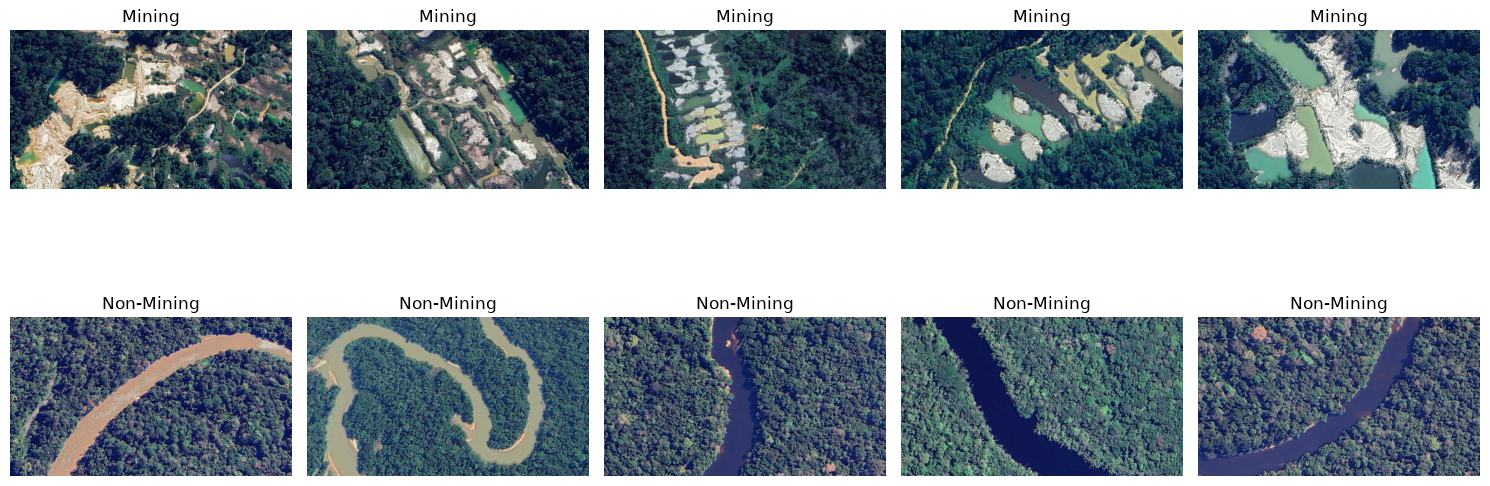

In [11]:
import matplotlib.pyplot as plt
from PIL import Image

# Select 5 mining images and 5 non-mining images
sample_mining = mining_images[:5]
sample_non_mining = non_mining_images[:5]

# Create figure
fig, axes = plt.subplots(2, 5, figsize=(15, 7))

# Display mining images
for i, image_path in enumerate(sample_mining):
    image = Image.open(image_path)

    axes[0, i].imshow(image)
    axes[0, i].set_title("Mining")
    axes[0, i].axis("off")

# Display non-mining images
for i, image_path in enumerate(sample_non_mining):
    image = Image.open(image_path)

    axes[1, i].imshow(image)
    axes[1, i].set_title("Non-Mining")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [12]:
from PIL import Image

# Check image dimensions and corrupted files

all_images = mining_images + non_mining_images

corrupted_images = []
image_sizes = []

for image_path in all_images:
    try:
        with Image.open(image_path) as img:
            image_sizes.append(img.size)
    except Exception:
        corrupted_images.append(image_path)

print("========== IMAGE QUALITY CHECK ==========")
print(f"Total images checked : {len(all_images)}")
print(f"Corrupted images     : {len(corrupted_images)}")

print("\n========== IMAGE SIZE EXAMPLES ==========")
for size in image_sizes[:10]:
    print(size)

========== IMAGE QUALITY CHECK ==========
Total images checked : 2006
Corrupted images     : 0

========== IMAGE SIZE EXAMPLES ==========
(1280, 720)
(1280, 720)
(1280, 720)
(1280, 720)
(1280, 720)
(1280, 720)
(1280, 720)
(1280, 720)
(1280, 720)
(1280, 720)


In [13]:
from sklearn.model_selection import train_test_split

# Create labels
X = mining_images + non_mining_images
y = [1] * len(mining_images) + [0] * len(non_mining_images)

# First split: 70% training, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: divide temporary set equally
# 15% validation + 15% testing
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("========== DATASET SPLIT ==========")
print(f"Training images   : {len(X_train)}")
print(f"Validation images : {len(X_val)}")
print(f"Testing images    : {len(X_test)}")

print("\n========== TOTAL ==========")
print(f"Total images      : {len(X_train) + len(X_val) + len(X_test)}")

========== DATASET SPLIT ==========
Training images   : 1404
Validation images : 301
Testing images    : 301

========== TOTAL ==========
Total images      : 2006


In [14]:
from collections import Counter

print("========== CLASS DISTRIBUTION ==========")

print("\nTraining:")
print("Mining     :", Counter(y_train)[1])
print("Non-Mining :", Counter(y_train)[0])

print("\nValidation:")
print("Mining     :", Counter(y_val)[1])
print("Non-Mining :", Counter(y_val)[0])

print("\nTesting:")
print("Mining     :", Counter(y_test)[1])
print("Non-Mining :", Counter(y_test)[0])

========== CLASS DISTRIBUTION ==========

Training:
Mining     : 707
Non-Mining : 697

Validation:
Mining     : 152
Non-Mining : 149

Testing:
Mining     : 151
Non-Mining : 150


In [15]:
import torch
from torchvision import transforms

# Image preprocessing
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

print("Image preprocessing pipeline created successfully!")

Image preprocessing pipeline created successfully!


In [16]:
from torch.utils.data import Dataset
from PIL import Image


class MiningDataset(Dataset):

    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image_path = self.image_paths[index]
        label = self.labels[index]

        # Open image
        image = Image.open(image_path).convert("RGB")

        # Apply preprocessing
        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)


# Create datasets
train_dataset = MiningDataset(
    X_train,
    y_train,
    transform=image_transform
)

val_dataset = MiningDataset(
    X_val,
    y_val,
    transform=image_transform
)

test_dataset = MiningDataset(
    X_test,
    y_test,
    transform=image_transform
)

print("========== PYTORCH DATASETS ==========")
print("Training dataset   :", len(train_dataset))
print("Validation dataset :", len(val_dataset))
print("Testing dataset    :", len(test_dataset))

========== PYTORCH DATASETS ==========
Training dataset   : 1404
Validation dataset : 301
Testing dataset    : 301


In [17]:
# Get one image from the training dataset
image, label = train_dataset[0]

print("========== SAMPLE DATA ==========")
print("Image shape :", image.shape)
print("Image type  :", type(image))
print("Label       :", label.item())

if label.item() == 1:
    print("Class       : Mining")
else:
    print("Class       : Non-Mining")

========== SAMPLE DATA ==========
Image shape : torch.Size([3, 224, 224])
Image type  : <class 'torch.Tensor'>
Label       : 0
Class       : Non-Mining


In [18]:
from torch.utils.data import DataLoader

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("========== DATALOADERS ==========")
print("Training batches   :", len(train_loader))
print("Validation batches :", len(val_loader))
print("Testing batches    :", len(test_loader))

========== DATALOADERS ==========
Training batches   : 44
Validation batches : 10
Testing batches    : 10


In [19]:
# Get one batch from the training DataLoader
images, labels = next(iter(train_loader))

print("========== BATCH TEST ==========")
print("Images shape :", images.shape)
print("Labels shape :", labels.shape)
print("Labels       :", labels[:10])

========== BATCH TEST ==========
Images shape : torch.Size([32, 3, 224, 224])
Labels shape : torch.Size([32])
Labels       : tensor([1, 0, 1, 0, 0, 0, 1, 0, 0, 0])


In [20]:
import torch.nn as nn


class MiningCNN(nn.Module):

    def __init__(self):
        super(MiningCNN, self).__init__()

        self.features = nn.Sequential(

            # Convolution Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Convolution Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Convolution Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 28 * 28, 128),
            nn.ReLU(),

            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Create the model
model = MiningCNN()

print(model)

MiningCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [21]:
import torch
import torch.nn as nn
import torch.optim as optim

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move model to device
model = model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("========== TRAINING SETUP ==========")
print("Device    :", device)
print("Loss      : CrossEntropyLoss")
print("Optimizer : Adam")
print("Learning rate : 0.001")

========== TRAINING SETUP ==========
Device    : cpu
Loss      : CrossEntropyLoss
Optimizer : Adam
Learning rate : 0.001


In [22]:
num_epochs = 10

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []


for epoch in range(num_epochs):

    # =========================
    # TRAINING
    # =========================
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update model weights
        optimizer.step()

        # Statistics
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total


    # =========================
    # VALIDATION
    # =========================
    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total


    # Save results
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.2f}%"
    )

Epoch [1/10] Train Loss: 0.4216 Train Acc: 80.84% Val Loss: 0.2701 Val Acc: 90.03%
Epoch [2/10] Train Loss: 0.1035 Train Acc: 95.94% Val Loss: 0.1891 Val Acc: 91.36%
Epoch [3/10] Train Loss: 0.0886 Train Acc: 96.37% Val Loss: 0.0505 Val Acc: 98.34%
Epoch [4/10] Train Loss: 0.0473 Train Acc: 98.43% Val Loss: 0.0340 Val Acc: 99.34%
Epoch [5/10] Train Loss: 0.0338 Train Acc: 98.79% Val Loss: 0.0616 Val Acc: 98.34%
Epoch [6/10] Train Loss: 0.0375 Train Acc: 98.79% Val Loss: 0.1064 Val Acc: 96.35%
Epoch [7/10] Train Loss: 0.0478 Train Acc: 98.01% Val Loss: 0.0325 Val Acc: 99.34%
Epoch [8/10] Train Loss: 0.0228 Train Acc: 99.50% Val Loss: 0.0599 Val Acc: 98.34%
Epoch [9/10] Train Loss: 0.0163 Train Acc: 99.43% Val Loss: 0.0374 Val Acc: 99.00%
Epoch [10/10] Train Loss: 0.0109 Train Acc: 99.79% Val Loss: 0.0391 Val Acc: 99.00%


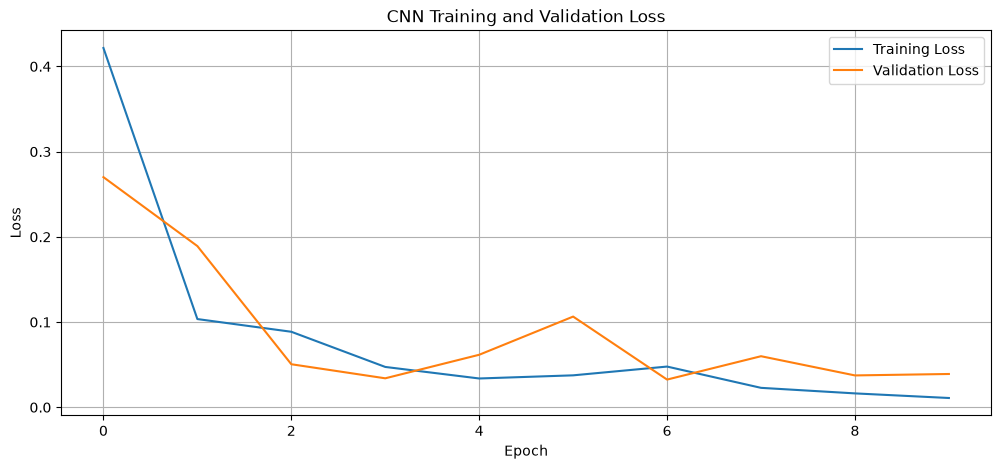

In [23]:
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(12, 5))

# Training and validation loss
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

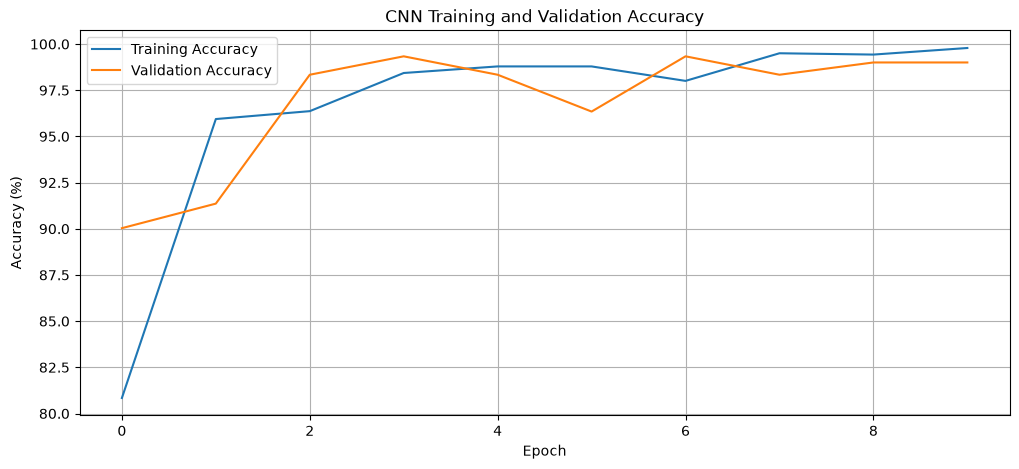

In [24]:
plt.figure(figsize=(12, 5))

# Training and validation accuracy
plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid()

plt.show()

In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Put model in evaluation mode
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Make predictions
        outputs = model(images)

        # Get predicted class
        _, predicted = torch.max(outputs, 1)

        # Store predictions and actual labels
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


# Calculate metrics
accuracy = accuracy_score(all_labels, all_predictions)

precision = precision_score(
    all_labels,
    all_predictions,
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_predictions,
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_predictions,
    zero_division=0
)

print("========== CNN TEST RESULTS ==========")
print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall * 100:.2f}%")
print(f"F1-Score  : {f1 * 100:.2f}%")

print("\n========== CLASSIFICATION REPORT ==========")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=["Non-Mining", "Mining"],
        zero_division=0
    )
)

========== CNN TEST RESULTS ==========
Accuracy  : 99.00%
Precision : 98.68%
Recall    : 99.34%
F1-Score  : 99.01%

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

  Non-Mining       0.99      0.99      0.99       150
      Mining       0.99      0.99      0.99       151

    accuracy                           0.99       301
   macro avg       0.99      0.99      0.99       301
weighted avg       0.99      0.99      0.99       301



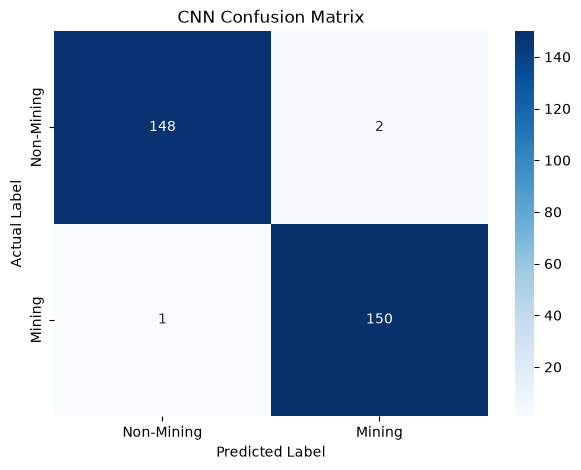

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Plot
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Mining", "Mining"],
    yticklabels=["Non-Mining", "Mining"]
)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [27]:
from pathlib import Path
import torch

# Create models folder if it doesn't exist
models_path = project_path / "models"
models_path.mkdir(exist_ok=True)

# Save the trained CNN
baseline_model_path = models_path / "baseline_cnn.pth"

torch.save(model.state_dict(), baseline_model_path)

print("Baseline CNN saved successfully!")
print("Saved at:")
print(baseline_model_path)

Baseline CNN saved successfully!
Saved at:
c:\Users\HP\OneDrive\Desktop\illegal mining.data\models\baseline_cnn.pth


In [28]:
from torchvision import models
import torch.nn as nn

# Load ResNet18
resnet_model = models.resnet18(weights="DEFAULT")

# Get number of inputs to the final layer
num_features = resnet_model.fc.in_features

# Replace the final classification layer
resnet_model.fc = nn.Linear(num_features, 2)

# Move model to CPU/GPU
resnet_model = resnet_model.to(device)

print("========== RESNET18 MODEL ==========")
print("Model : ResNet18")
print("Input features to final layer :", num_features)
print("Output classes                : 2")
print("Device                        :", device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\HP/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


========== RESNET18 MODEL ==========
Model : ResNet18
Input features to final layer : 512
Output classes                : 2
Device                        : cpu


In [29]:
import torch.optim as optim

# Loss function
resnet_criterion = nn.CrossEntropyLoss()

# Optimizer
resnet_optimizer = optim.Adam(
    resnet_model.parameters(),
    lr=0.0001
)

print("========== RESNET18 TRAINING SETUP ==========")
print("Loss           : CrossEntropyLoss")
print("Optimizer      : Adam")
print("Learning rate  : 0.0001")
print("Device         :", device)

========== RESNET18 TRAINING SETUP ==========
Loss           : CrossEntropyLoss
Optimizer      : Adam
Learning rate  : 0.0001
Device         : cpu


In [30]:
from torchvision import transforms

# ImageNet normalization used by the pretrained ResNet18
resnet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("ResNet18 preprocessing pipeline created successfully!")

ResNet18 preprocessing pipeline created successfully!


In [31]:
# Create ResNet18 datasets

resnet_train_dataset = MiningDataset(
    X_train,
    y_train,
    transform=resnet_transform
)

resnet_val_dataset = MiningDataset(
    X_val,
    y_val,
    transform=resnet_transform
)

resnet_test_dataset = MiningDataset(
    X_test,
    y_test,
    transform=resnet_transform
)

print("========== RESNET18 DATASETS ==========")
print("Training dataset   :", len(resnet_train_dataset))
print("Validation dataset :", len(resnet_val_dataset))
print("Testing dataset    :", len(resnet_test_dataset))

========== RESNET18 DATASETS ==========
Training dataset   : 1404
Validation dataset : 301
Testing dataset    : 301


In [32]:
from torch.utils.data import DataLoader

# ResNet18 DataLoaders
resnet_train_loader = DataLoader(
    resnet_train_dataset,
    batch_size=32,
    shuffle=True
)

resnet_val_loader = DataLoader(
    resnet_val_dataset,
    batch_size=32,
    shuffle=False
)

resnet_test_loader = DataLoader(
    resnet_test_dataset,
    batch_size=32,
    shuffle=False
)

print("========== RESNET18 DATALOADERS ==========")
print("Training batches   :", len(resnet_train_loader))
print("Validation batches :", len(resnet_val_loader))
print("Testing batches    :", len(resnet_test_loader))

========== RESNET18 DATALOADERS ==========
Training batches   : 44
Validation batches : 10
Testing batches    : 10


In [33]:
# Get one batch from the ResNet18 training DataLoader
resnet_images, resnet_labels = next(iter(resnet_train_loader))

print("========== RESNET18 BATCH TEST ==========")
print("Images shape :", resnet_images.shape)
print("Labels shape :", resnet_labels.shape)
print("Labels       :", resnet_labels[:10])

========== RESNET18 BATCH TEST ==========
Images shape : torch.Size([32, 3, 224, 224])
Labels shape : torch.Size([32])
Labels       : tensor([0, 1, 1, 1, 1, 1, 0, 1, 1, 1])


In [34]:
num_epochs = 10

resnet_train_losses = []
resnet_val_losses = []

resnet_train_accuracies = []
resnet_val_accuracies = []


for epoch in range(num_epochs):

    # =========================
    # TRAINING
    # =========================
    resnet_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in resnet_train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear gradients
        resnet_optimizer.zero_grad()

        # Forward pass
        outputs = resnet_model(images)

        # Calculate loss
        loss = resnet_criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        resnet_optimizer.step()

        # Statistics
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(resnet_train_loader)
    train_accuracy = 100 * correct / total


    # =========================
    # VALIDATION
    # =========================
    resnet_model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in resnet_val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = resnet_model(images)

            loss = resnet_criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(resnet_val_loader)
    val_accuracy = 100 * val_correct / val_total


    # Save results
    resnet_train_losses.append(train_loss)
    resnet_val_losses.append(val_loss)

    resnet_train_accuracies.append(train_accuracy)
    resnet_val_accuracies.append(val_accuracy)


    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.2f}%"
    )

Epoch [1/10] Train Loss: 0.0481 Train Acc: 98.01% Val Loss: 0.0026 Val Acc: 100.00%
Epoch [2/10] Train Loss: 0.0028 Train Acc: 99.93% Val Loss: 0.0073 Val Acc: 99.67%
Epoch [3/10] Train Loss: 0.0008 Train Acc: 100.00% Val Loss: 0.0011 Val Acc: 100.00%
Epoch [4/10] Train Loss: 0.0006 Train Acc: 100.00% Val Loss: 0.0009 Val Acc: 100.00%
Epoch [5/10] Train Loss: 0.0004 Train Acc: 100.00% Val Loss: 0.0043 Val Acc: 99.67%
Epoch [6/10] Train Loss: 0.0008 Train Acc: 100.00% Val Loss: 0.0047 Val Acc: 99.67%
Epoch [7/10] Train Loss: 0.0002 Train Acc: 100.00% Val Loss: 0.0056 Val Acc: 99.67%
Epoch [8/10] Train Loss: 0.0002 Train Acc: 100.00% Val Loss: 0.0085 Val Acc: 99.67%
Epoch [9/10] Train Loss: 0.0002 Train Acc: 100.00% Val Loss: 0.0091 Val Acc: 99.67%
Epoch [10/10] Train Loss: 0.0001 Train Acc: 100.00% Val Loss: 0.0087 Val Acc: 99.67%


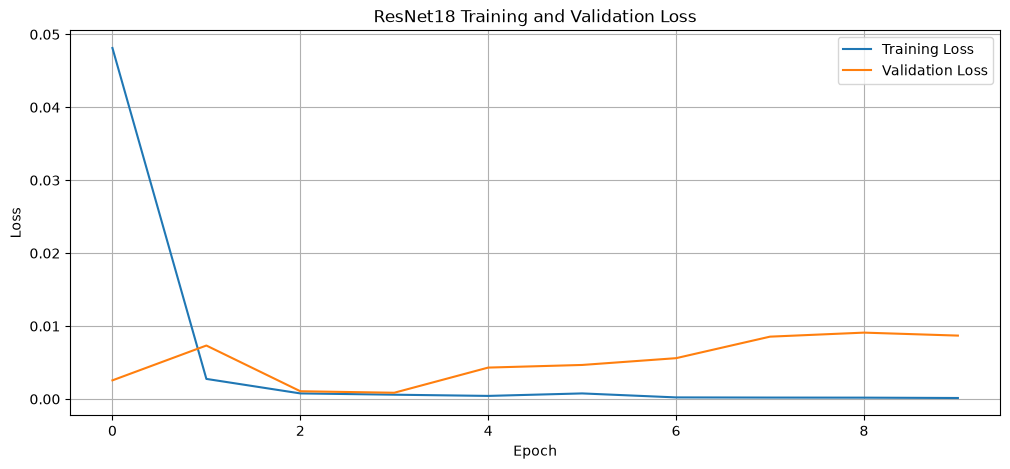

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    resnet_train_losses,
    label="Training Loss"
)

plt.plot(
    resnet_val_losses,
    label="Validation Loss"
)

plt.title("ResNet18 Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

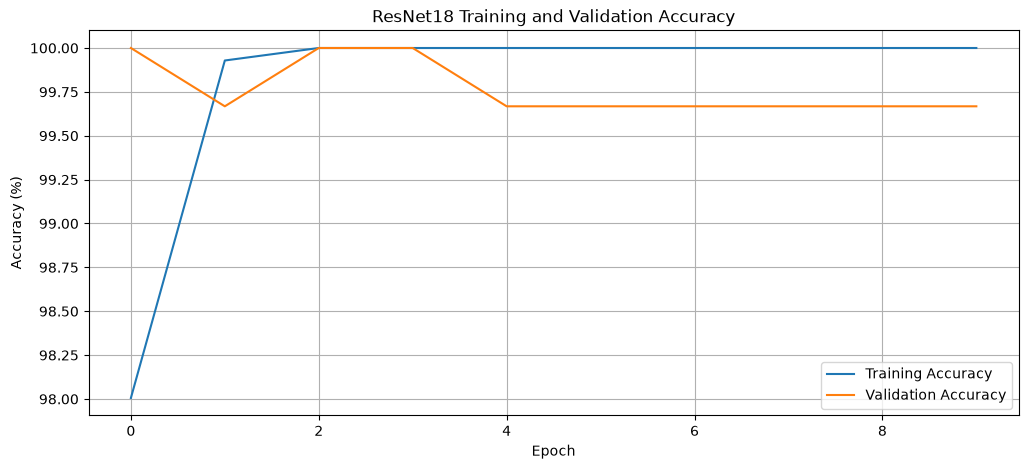

In [36]:
plt.figure(figsize=(12, 5))

plt.plot(
    resnet_train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    resnet_val_accuracies,
    label="Validation Accuracy"
)

plt.title("ResNet18 Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid()

plt.show()

In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

resnet_model.eval()

resnet_all_predictions = []
resnet_all_labels = []

with torch.no_grad():
    for images, labels in resnet_test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = resnet_model(images)
        _, predicted = torch.max(outputs, 1)

        resnet_all_predictions.extend(predicted.cpu().numpy())
        resnet_all_labels.extend(labels.cpu().numpy())

# Calculate metrics
resnet_accuracy = accuracy_score(
    resnet_all_labels,
    resnet_all_predictions
)

resnet_precision = precision_score(
    resnet_all_labels,
    resnet_all_predictions,
    zero_division=0
)

resnet_recall = recall_score(
    resnet_all_labels,
    resnet_all_predictions,
    zero_division=0
)

resnet_f1 = f1_score(
    resnet_all_labels,
    resnet_all_predictions,
    zero_division=0
)

print("========== RESNET18 TEST RESULTS ==========")
print(f"Accuracy  : {resnet_accuracy * 100:.2f}%")
print(f"Precision : {resnet_precision * 100:.2f}%")
print(f"Recall    : {resnet_recall * 100:.2f}%")
print(f"F1-Score  : {resnet_f1 * 100:.2f}%")

print("\n========== CLASSIFICATION REPORT ==========")

print(
    classification_report(
        resnet_all_labels,
        resnet_all_predictions,
        target_names=["Non-Mining", "Mining"],
        zero_division=0
    )
)

========== RESNET18 TEST RESULTS ==========
Accuracy  : 100.00%
Precision : 100.00%
Recall    : 100.00%
F1-Score  : 100.00%

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

  Non-Mining       1.00      1.00      1.00       150
      Mining       1.00      1.00      1.00       151

    accuracy                           1.00       301
   macro avg       1.00      1.00      1.00       301
weighted avg       1.00      1.00      1.00       301



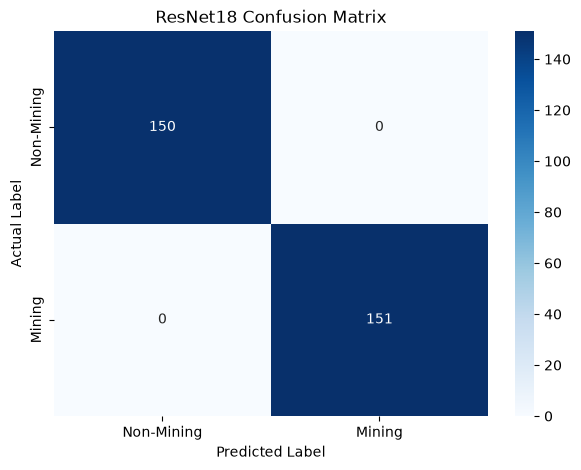

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_resnet = confusion_matrix(
    resnet_all_labels,
    resnet_all_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_resnet,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Mining", "Mining"],
    yticklabels=["Non-Mining", "Mining"]
)

plt.title("ResNet18 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [39]:
resnet_model_path = models_path / "resnet18_mining.pth"

torch.save(
    resnet_model.state_dict(),
    resnet_model_path
)

print("ResNet18 model saved successfully!")
print("Saved at:", resnet_model_path)

ResNet18 model saved successfully!
Saved at: c:\Users\HP\OneDrive\Desktop\illegal mining.data\models\resnet18_mining.pth
